In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import sys
from os.path import exists

sys.path.append('../..')

In [3]:
from loguru import logger
import numpy as np
from stable_baselines3.common.env_checker import check_env

# Sequential DDA environment test

In [4]:
from vimms.Common import POSITIVE, load_obj, save_obj
from vimms.ChemicalSamplers import MZMLFormulaSampler, MZMLRTandIntensitySampler, \
    MZMLChromatogramSampler
from vimms.Roi import RoiBuilderParams

from vimms_gym.env import DDAEnv
from vimms_gym.features import obs_to_dfs

/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex
/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/psims/mzmlb/writer.py:15: UserWarning: hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.
  warnings.warn(


In [5]:
n_chemicals = (5000, 20000)
mz_range = (70, 1000)
rt_range = (0, 1440)
intensity_range = (1E4, 1E20)

In [6]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [7]:
isolation_window = 0.7
N = 10
rt_tol = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1E3

In [8]:
mzml_filename = '../fullscan_QCB.mzML'
samplers = None
samplers_pickle = 'samplers_fullscan_QCB.mzML.p'
if exists(samplers_pickle):
    logger.info('Loaded %s' % samplers_pickle)
    samplers = load_obj(samplers_pickle)
    mz_sampler = samplers['mz']
    ri_sampler = samplers['rt_intensity']
    cr_sampler = samplers['chromatogram']
else:
    logger.info('Creating samplers from %s' % mzml_filename)
    mz_sampler = MZMLFormulaSampler(mzml_filename, min_mz=min_mz, max_mz=max_mz)
    ri_sampler = MZMLRTandIntensitySampler(mzml_filename, min_rt=min_rt, max_rt=max_rt,
                                           min_log_intensity=min_log_intensity,
                                           max_log_intensity=max_log_intensity)
    roi_params = RoiBuilderParams(min_roi_length=3, at_least_one_point_above=1000)
    cr_sampler = MZMLChromatogramSampler(mzml_filename, roi_params=roi_params)
    samplers = {
        'mz': mz_sampler,
        'rt_intensity': ri_sampler,
        'chromatogram': cr_sampler
    }
    save_obj(samplers, samplers_pickle)

2022-04-26 16:54:18.740 | INFO     | __main__:<module>:5 - Loaded samplers_fullscan_QCB.mzML.p


In [9]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': cr_sampler,
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

Initialise a new DDA environment that tracks the top most intense peaks.

In [10]:
max_peaks = 100
env = DDAEnv(max_peaks, params)
check_env(env)

Generate an initial observation (MS1 scan)

In [11]:
observation = env.reset()
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

(    intensities  fragmented  excluded  roi_length  \
 0      0.149957         0.0       0.0         0.0   
 1      0.149942         0.0       0.0         0.0   
 2      0.149799         0.0       0.0         0.0   
 3      0.149701         0.0       0.0         0.0   
 4      0.149345         0.0       0.0         0.0   
 ..          ...         ...       ...         ...   
 95     0.000000         0.0       0.0         0.0   
 96     0.000000         0.0       0.0         0.0   
 97     0.000000         0.0       0.0         0.0   
 98     0.000000         0.0       0.0         0.0   
 99     0.000000         0.0       0.0         0.0   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                                0.0                         0.0   
 1                                0.0                         0.0   
 2                                0.0                         0.0   
 3                                0.0                         0.0   
 4   

In [12]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [13]:
env.features

[mz=916.4416081914761 rt=0 intensity=998.0005933345501 (0.1499565399742806) roi=ROI with data points=1 fragmentations=0 mz (916.4416-916.4416) rt (0.0000-0.0000),
 mz=508.80914793730454 rt=0 intensity=997.3410400324908 (0.14994218451929245) roi=ROI with data points=1 fragmentations=0 mz (508.8091-508.8091) rt (0.0000-0.0000),
 mz=170.8621770546451 rt=0 intensity=990.8028820650435 (0.14979936305995745) roi=ROI with data points=1 fragmentations=0 mz (170.8622-170.8622) rt (0.0000-0.0000),
 mz=486.42227413402367 rt=0 intensity=986.3287449362431 (0.14970108450548014) roi=ROI with data points=1 fragmentations=0 mz (486.4223-486.4223) rt (0.0000-0.0000),
 mz=169.00392156685976 rt=0 intensity=970.3051819117342 (0.14934541753676062) roi=ROI with data points=1 fragmentations=0 mz (169.0039-169.0039) rt (0.0000-0.0000),
 mz=697.0831485896823 rt=0 intensity=962.5220288986105 (0.14917053389186483) roi=ROI with data points=1 fragmentations=0 mz (697.0831-697.0831) rt (0.0000-0.0000),
 mz=379.745069

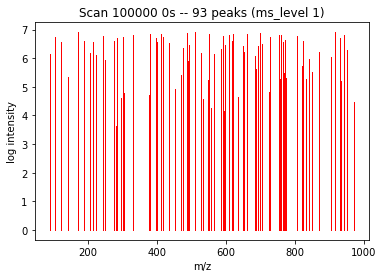

In [14]:
env.render()

Generate a lot of ms1 scans

In [15]:
for i in range(200):
    action = max_peaks  # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward -0.1
done False


(    intensities  fragmented  excluded  roi_length  \
 0      0.215014         0.0       0.0       0.160   
 1      0.206430         0.0       0.0       0.004   
 2      0.201331         0.0       0.0       0.096   
 3      0.149936         0.0       0.0       0.000   
 4      0.149903         0.0       0.0       0.000   
 ..          ...         ...       ...         ...   
 95     0.056174         0.0       0.0       0.000   
 96     0.055673         0.0       0.0       0.000   
 97     0.000000         0.0       0.0       0.000   
 98     0.000000         0.0       0.0       0.000   
 99     0.000000         0.0       0.0       0.000   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                                0.0                         0.0   
 1                                0.0                         0.0   
 2                                0.0                         0.0   
 3                                0.0                         0.0   
 4   

In [16]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1.],
      dtype=float32)

In [17]:
env.features

[mz=262.04226103973514 rt=80.00000000000006 intensity=19965.235507074318 (0.21501372187182105) roi=ROI with data points=41 fragmentations=0 mz (262.0422-262.0423) rt (64.0000-80.0000),
 mz=146.74859652949203 rt=80.00000000000006 intensity=13446.363110150924 (0.20643024174562882) roi=ROI with data points=2 fragmentations=0 mz (146.7483-146.7486) rt (79.6000-80.0000),
 mz=121.80482418568748 rt=80.00000000000006 intensity=10632.203615383109 (0.20133116425541778) roi=ROI with data points=25 fragmentations=0 mz (121.8045-121.8048) rt (70.4000-80.0000),
 mz=530.6050744873728 rt=80.00000000000006 intensity=997.0481981541204 (0.14993580764910458) roi=ROI with data points=1 fragmentations=0 mz (530.6051-530.6051) rt (80.0000-80.0000),
 mz=608.5682567588005 rt=80.00000000000006 intensity=995.5606848942965 (0.1499033868902692) roi=ROI with data points=1 fragmentations=0 mz (608.5683-608.5683) rt (80.0000-80.0000),
 mz=238.67027943496478 rt=80.00000000000006 intensity=985.1853026343572 (0.14967589

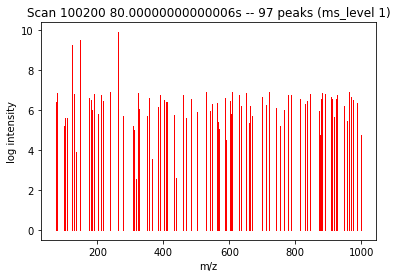

In [18]:
env.render()

Target the most intense precursor for fragmentation, and generate an MS2 scan from that

In [19]:
action = 0
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward 0.2741195587881456
done False


(    intensities  fragmented  excluded  roi_length  \
 0      0.215014         0.2  0.026667       0.160   
 1      0.206430         0.0  0.000000       0.004   
 2      0.201331         0.0  0.000000       0.096   
 3      0.149936         0.0  0.000000       0.000   
 4      0.149903         0.0  0.000000       0.000   
 ..          ...         ...       ...         ...   
 95     0.056174         0.0  0.000000       0.000   
 96     0.055673         0.0  0.000000       0.000   
 97     0.000000         0.0  0.000000       0.000   
 98     0.000000         0.0  0.000000       0.000   
 99     0.000000         0.0  0.000000       0.000   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                                0.0                         0.0   
 1                                0.0                         0.0   
 2                                0.0                         0.0   
 3                                0.0                         0.0   
 4   

In [20]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1.],
      dtype=float32)

In [21]:
env.features

[mz=262.04226103973514 rt=80.00000000000006 intensity=19965.235507074318 (0.21501372187182105) roi=ROI with data points=41 fragmentations=0 mz (262.0422-262.0423) rt (64.0000-80.0000),
 mz=146.74859652949203 rt=80.00000000000006 intensity=13446.363110150924 (0.20643024174562882) roi=ROI with data points=2 fragmentations=0 mz (146.7483-146.7486) rt (79.6000-80.0000),
 mz=121.80482418568748 rt=80.00000000000006 intensity=10632.203615383109 (0.20133116425541778) roi=ROI with data points=25 fragmentations=0 mz (121.8045-121.8048) rt (70.4000-80.0000),
 mz=530.6050744873728 rt=80.00000000000006 intensity=997.0481981541204 (0.14993580764910458) roi=ROI with data points=1 fragmentations=0 mz (530.6051-530.6051) rt (80.0000-80.0000),
 mz=608.5682567588005 rt=80.00000000000006 intensity=995.5606848942965 (0.1499033868902692) roi=ROI with data points=1 fragmentations=0 mz (608.5683-608.5683) rt (80.0000-80.0000),
 mz=238.67027943496478 rt=80.00000000000006 intensity=985.1853026343572 (0.14967589

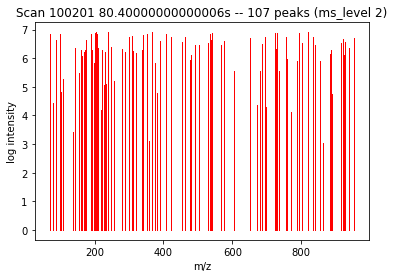

In [22]:
env.render()

Target the next most intense precursor for fragmentation, and generate an MS2 scan

In [23]:
action = 1
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward 0.23770316843488523
done False


(    intensities  fragmented  excluded  roi_length  \
 0      0.215014         0.2      0.04       0.160   
 1      0.206430         0.2      0.04       0.004   
 2      0.201331         0.0      0.00       0.096   
 3      0.149936         0.0      0.00       0.000   
 4      0.149903         0.0      0.00       0.000   
 ..          ...         ...       ...         ...   
 95     0.056174         0.0      0.00       0.000   
 96     0.055673         0.0      0.00       0.000   
 97     0.000000         0.0      0.00       0.000   
 98     0.000000         0.0      0.00       0.000   
 99     0.000000         0.0      0.00       0.000   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                                0.0                         0.0   
 1                                0.0                         0.0   
 2                                0.0                         0.0   
 3                                0.0                         0.0   
 4   

In [24]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1.],
      dtype=float32)

In [25]:
env.features

[mz=262.04226103973514 rt=80.00000000000006 intensity=19965.235507074318 (0.21501372187182105) roi=ROI with data points=41 fragmentations=0 mz (262.0422-262.0423) rt (64.0000-80.0000),
 mz=146.74859652949203 rt=80.00000000000006 intensity=13446.363110150924 (0.20643024174562882) roi=ROI with data points=2 fragmentations=0 mz (146.7483-146.7486) rt (79.6000-80.0000),
 mz=121.80482418568748 rt=80.00000000000006 intensity=10632.203615383109 (0.20133116425541778) roi=ROI with data points=25 fragmentations=0 mz (121.8045-121.8048) rt (70.4000-80.0000),
 mz=530.6050744873728 rt=80.00000000000006 intensity=997.0481981541204 (0.14993580764910458) roi=ROI with data points=1 fragmentations=0 mz (530.6051-530.6051) rt (80.0000-80.0000),
 mz=608.5682567588005 rt=80.00000000000006 intensity=995.5606848942965 (0.1499033868902692) roi=ROI with data points=1 fragmentations=0 mz (608.5683-608.5683) rt (80.0000-80.0000),
 mz=238.67027943496478 rt=80.00000000000006 intensity=985.1853026343572 (0.14967589

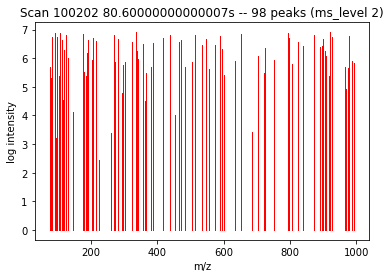

In [26]:
env.render()

Repeat targeting of the same precursor will end up targeting low-intensity spike noises (non-chemicals), which produce no reward

In [27]:
for i in range(10):
    action = 0
    observation, reward, done, info = env.step(action)
    print('reward', reward)
    # print('done', done)
    # pp.pprint(observation)
    # env.render()

reward 0.0034231853296146065
reward 0.0010343139664814132
reward -0.0009144901874481286
reward -0.0009547025728652426
reward -0.0009986147455111822
reward 0.0003688953467376995
reward 0.0008891381986088144
reward 0.0008541588368063782
reward 0.00029610623731509306
reward -0.0016932421362555925


In [28]:
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

(    intensities  fragmented  excluded  roi_length  \
 0      0.215014         1.0  0.173333       0.160   
 1      0.206430         0.2  0.173333       0.004   
 2      0.201331         0.0  0.000000       0.096   
 3      0.149936         0.0  0.000000       0.000   
 4      0.149903         0.0  0.000000       0.000   
 ..          ...         ...       ...         ...   
 95     0.056174         0.0  0.000000       0.000   
 96     0.055673         0.0  0.000000       0.000   
 97     0.000000         0.0  0.000000       0.000   
 98     0.000000         0.0  0.000000       0.000   
 99     0.000000         0.0  0.000000       0.000   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                                0.0                         0.0   
 1                                0.0                         0.0   
 2                                0.0                         0.0   
 3                                0.0                         0.0   
 4   

In [29]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1.],
      dtype=float32)

In [30]:
env.features

[mz=262.04226103973514 rt=80.00000000000006 intensity=19965.235507074318 (0.21501372187182105) roi=ROI with data points=41 fragmentations=0 mz (262.0422-262.0423) rt (64.0000-80.0000),
 mz=146.74859652949203 rt=80.00000000000006 intensity=13446.363110150924 (0.20643024174562882) roi=ROI with data points=2 fragmentations=0 mz (146.7483-146.7486) rt (79.6000-80.0000),
 mz=121.80482418568748 rt=80.00000000000006 intensity=10632.203615383109 (0.20133116425541778) roi=ROI with data points=25 fragmentations=0 mz (121.8045-121.8048) rt (70.4000-80.0000),
 mz=530.6050744873728 rt=80.00000000000006 intensity=997.0481981541204 (0.14993580764910458) roi=ROI with data points=1 fragmentations=0 mz (530.6051-530.6051) rt (80.0000-80.0000),
 mz=608.5682567588005 rt=80.00000000000006 intensity=995.5606848942965 (0.1499033868902692) roi=ROI with data points=1 fragmentations=0 mz (608.5683-608.5683) rt (80.0000-80.0000),
 mz=238.67027943496478 rt=80.00000000000006 intensity=985.1853026343572 (0.14967589

Making an invalid move produces negative reward.

In [31]:
action = 50  # no precursor to fragment at this index
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward 0.0
done False


(    intensities  fragmented  excluded  roi_length  \
 0      0.215014         1.0  0.186667       0.160   
 1      0.206430         0.2  0.186667       0.004   
 2      0.201331         0.0  0.000000       0.096   
 3      0.149936         0.0  0.000000       0.000   
 4      0.149903         0.0  0.000000       0.000   
 ..          ...         ...       ...         ...   
 95     0.056174         0.0  0.000000       0.000   
 96     0.055673         0.0  0.000000       0.000   
 97     0.000000         0.0  0.000000       0.000   
 98     0.000000         0.0  0.000000       0.000   
 99     0.000000         0.0  0.000000       0.000   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                                0.0                         0.0   
 1                                0.0                         0.0   
 2                                0.0                         0.0   
 3                                0.0                         0.0   
 4   

In [32]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1.],
      dtype=float32)

In [33]:
env.features

[mz=262.04226103973514 rt=80.00000000000006 intensity=19965.235507074318 (0.21501372187182105) roi=ROI with data points=41 fragmentations=0 mz (262.0422-262.0423) rt (64.0000-80.0000),
 mz=146.74859652949203 rt=80.00000000000006 intensity=13446.363110150924 (0.20643024174562882) roi=ROI with data points=2 fragmentations=0 mz (146.7483-146.7486) rt (79.6000-80.0000),
 mz=121.80482418568748 rt=80.00000000000006 intensity=10632.203615383109 (0.20133116425541778) roi=ROI with data points=25 fragmentations=0 mz (121.8045-121.8048) rt (70.4000-80.0000),
 mz=530.6050744873728 rt=80.00000000000006 intensity=997.0481981541204 (0.14993580764910458) roi=ROI with data points=1 fragmentations=0 mz (530.6051-530.6051) rt (80.0000-80.0000),
 mz=608.5682567588005 rt=80.00000000000006 intensity=995.5606848942965 (0.1499033868902692) roi=ROI with data points=1 fragmentations=0 mz (608.5683-608.5683) rt (80.0000-80.0000),
 mz=238.67027943496478 rt=80.00000000000006 intensity=985.1853026343572 (0.14967589

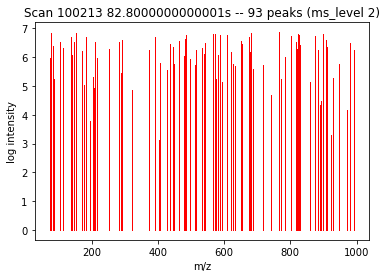

In [34]:
env.render()

Generate lots of MS1 scans

In [35]:
for i in range(100):
    action = max_peaks  # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward -0.1
done False


(    intensities  fragmented  excluded  roi_length  \
 0      0.228149         0.0       0.0       0.248   
 1      0.219729         0.0       0.0       0.586   
 2      0.205233         0.0       0.0       0.032   
 3      0.201109         0.0       0.0       0.076   
 4      0.197622         0.0       0.0       0.244   
 ..          ...         ...       ...         ...   
 95     0.071579         0.0       0.0       0.000   
 96     0.071360         0.0       0.0       0.000   
 97     0.065624         0.0       0.0       0.000   
 98     0.062990         0.0       0.0       0.000   
 99     0.036868         0.0       0.0       0.000   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                           0.000000                    0.000000   
 1                           0.037519                    0.215014   
 2                           0.000000                    0.000000   
 3                           0.000000                    0.000000   
 4   

In [36]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
      dtype=float32)

In [37]:
env.features

[mz=136.0757670145829 rt=122.60000000000066 intensity=36557.83864489966 (0.22814902558347724) roi=ROI with data points=63 fragmentations=0 mz (136.0757-136.0758) rt (97.8000-122.6000),
 mz=262.042227369899 rt=122.60000000000066 intensity=24807.377900032712 (0.21972904312347058) roi=ROI with data points=141 fragmentations=0 mz (262.0422-262.0422) rt (64.0000-122.6000),
 mz=104.08914874885362 rt=122.60000000000066 intensity=12724.833050281452 (0.205232604655284) roi=ROI with data points=9 fragmentations=0 mz (104.0891-104.0891) rt (119.4000-122.6000),
 mz=241.14467346303073 rt=122.60000000000066 intensity=10523.985501978095 (0.2011090120561296) roi=ROI with data points=20 fragmentations=0 mz (241.1446-241.1447) rt (115.0000-122.6000),
 mz=222.76649045793621 rt=122.60000000000066 intensity=8962.579553708589 (0.19762165117902752) roi=ROI with data points=62 fragmentations=0 mz (222.7665-222.7665) rt (98.2000-122.6000),
 mz=118.5890383009977 rt=122.60000000000066 intensity=8133.278744242091

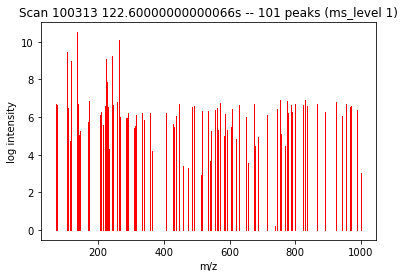

In [38]:
env.render()